In [1]:
# ========================================
# IMPORTS
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff

In [2]:
# ========================================
# LOAD DATASET
# ========================================
data, meta = arff.loadarff("data/customer_churn")
df = pd.DataFrame(data)

# decode byte strings from ARFF
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.decode("utf-8")

df["exited"] = df["exited"].astype(int)


In [3]:
# ========================================
# HELPER
# ========================================

def add_pct_labels(ax):
    """Annotate each stacked bar segment with its percentage."""
    for bar in ax.patches:
        h = bar.get_height()
        if h < 0.02:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_y() + h / 2,
            f"{h * 100:.1f}%",
            ha="center", va="center",
            fontsize=9, color="white", fontweight="bold"
        )


In [4]:
# ========================================
# DATASET OVERVIEW
# ========================================
print("\nDataset Info")
print("-" * 50)

print(df.info())

# print("\nMissing Values")
# display(df.isnull().sum().to_frame("missing"))

# print("\nSummary Statistics")
# display(df.describe().T)


Dataset Info
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 175028 entries, 0 to 175027
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   surname             175028 non-null  float64
 1   creditscore         175028 non-null  float64
 2   age                 175028 non-null  float64
 3   tenure              175028 non-null  float64
 4   balance             175028 non-null  float64
 5   numofproducts       175028 non-null  float64
 6   hascrcard           175028 non-null  float64
 7   isactivemember      175028 non-null  float64
 8   estimatedsalary     175028 non-null  float64
 9   exited              175028 non-null  int64  
 10  surname_tfidf_0     175028 non-null  float64
 11  surname_tfidf_1     175028 non-null  float64
 12  surname_tfidf_2     175028 non-null  float64
 13  surname_tfidf_3     175028 non-null  float64
 14  surname_tfidf_4     175028 non

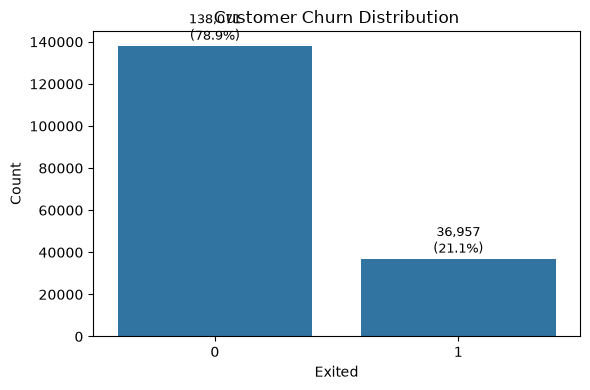

In [5]:
# ========================================
# TARGET DISTRIBUTION
# ========================================
fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(data=df, x="exited", ax=ax)

total = len(df)
for bar in ax.patches:
    count = int(bar.get_height())
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.005,
        f"{count:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Exited")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


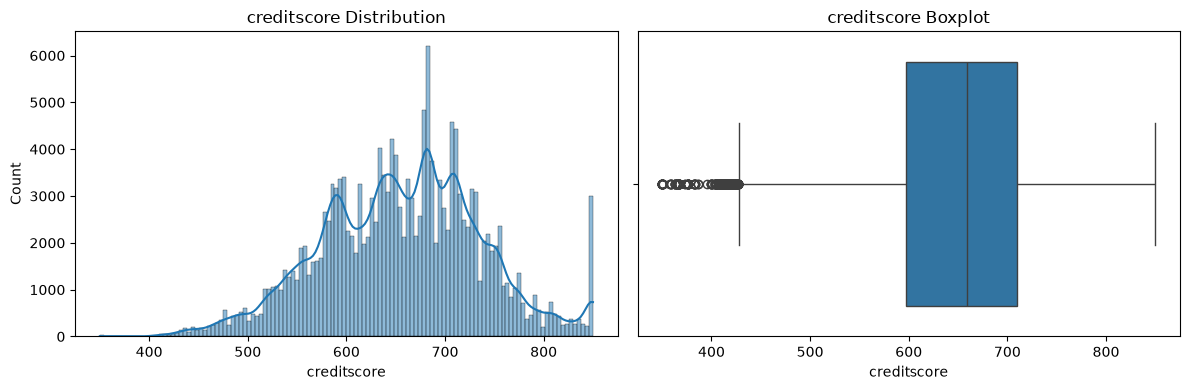

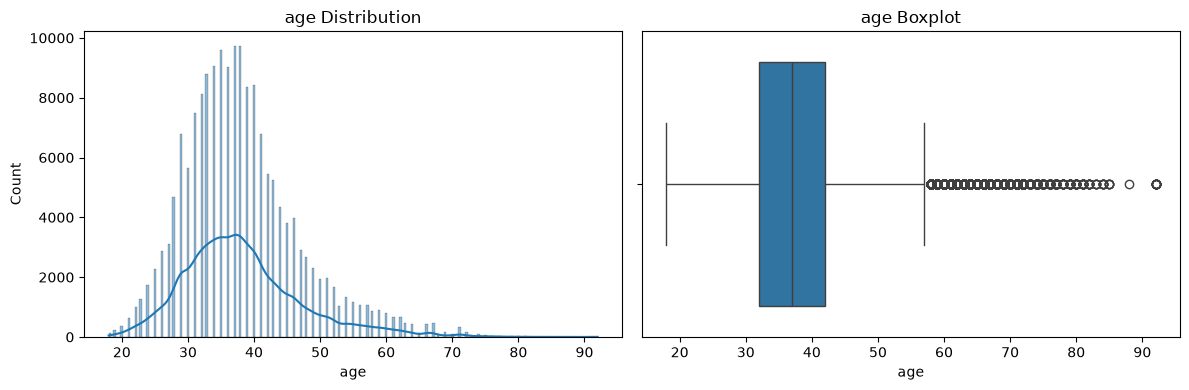

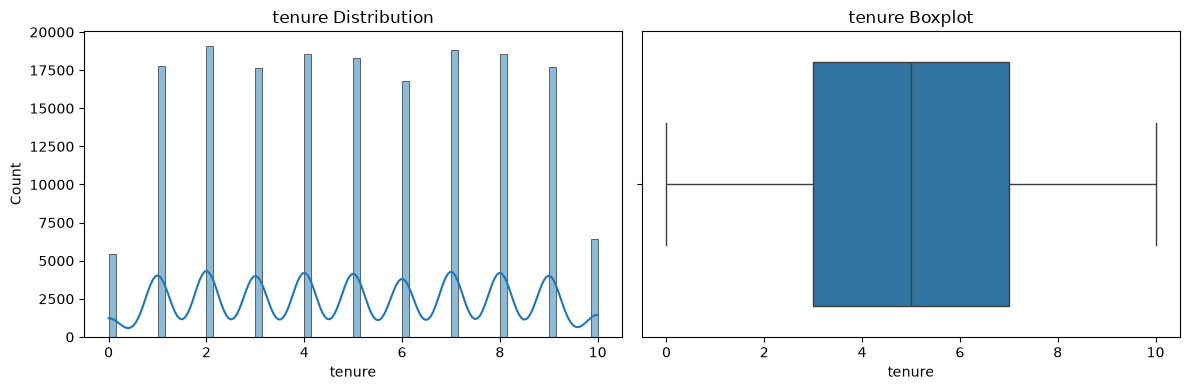

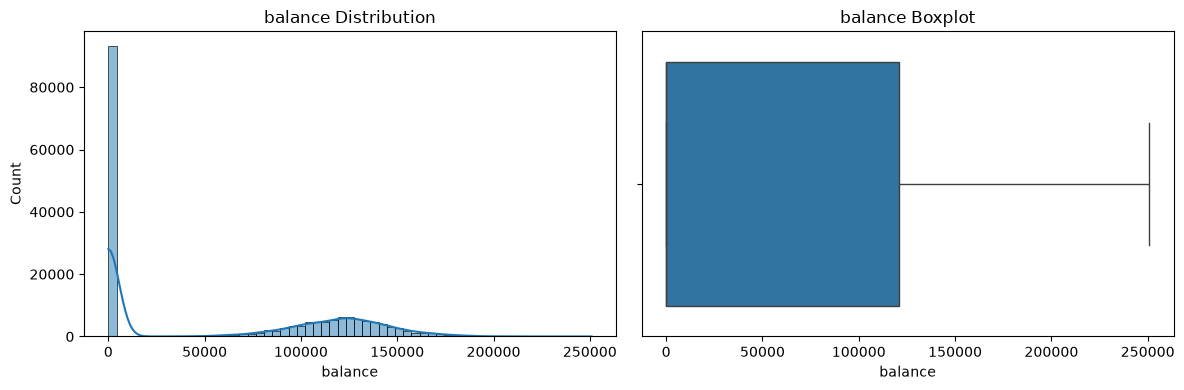

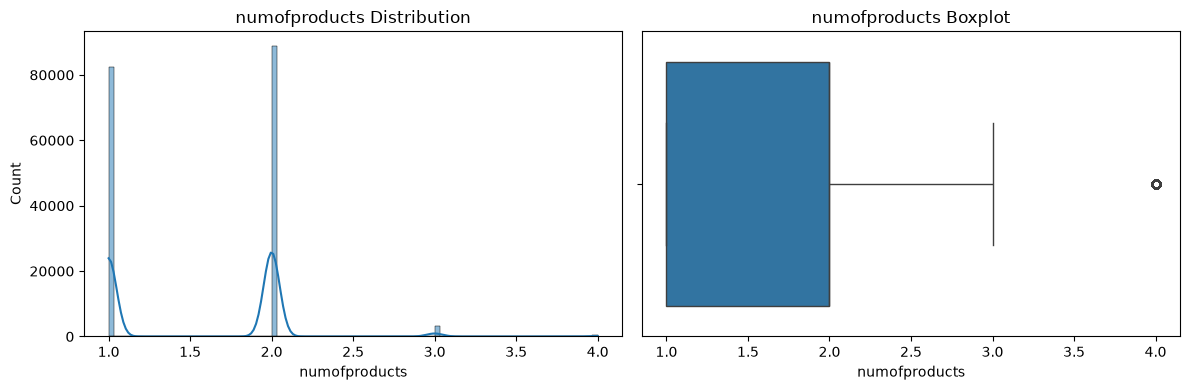

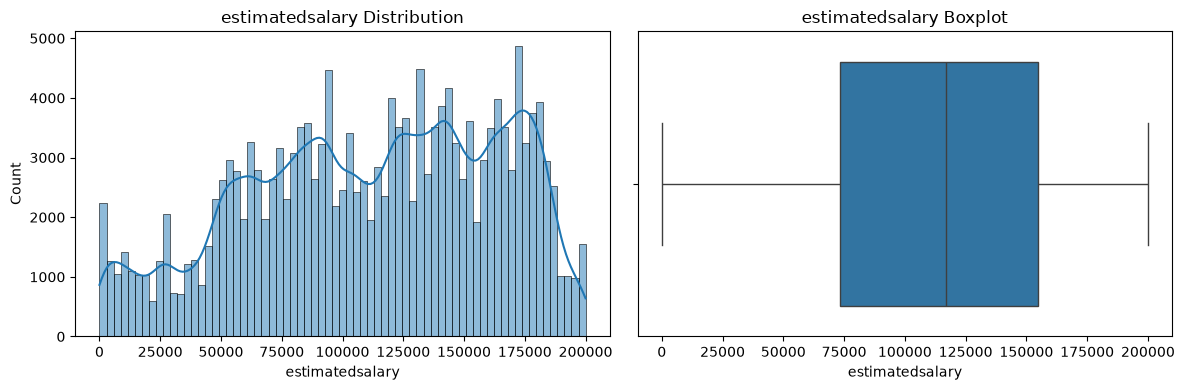

In [20]:
# ========================================
# NUMERICAL FEATURES DISTRIBUTION
# ========================================

business_features = [
    'creditscore',
    'age',
    'tenure',
    'balance',
    'numofproducts',
    'estimatedsalary'
]

for col in business_features:
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[col], kde=True, ax=axes[0])

    axes[0].set_title(f"{col} Distribution")

    sns.boxplot(x=df[col], ax=axes[1])

    axes[1].set_title(f"{col} Boxplot")

    plt.tight_layout()
    plt.show()

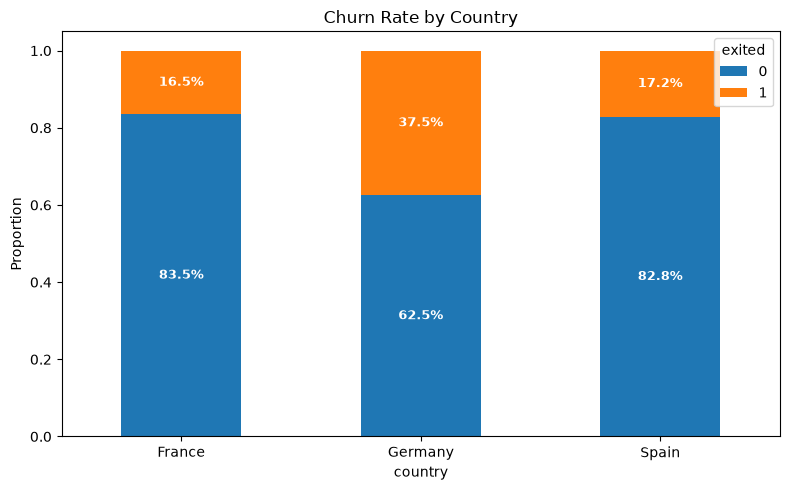

exited,0,1
country,,
France,82843,16382
Germany,23187,13927
Spain,32041,6648


In [6]:
# ========================================
# COUNTRY ANALYSIS
# ========================================

df['country'] = np.select(
    [df['france'] == 1, df['germany'] == 1, df['spain'] == 1],
    ["France", "Germany", "Spain"],
    default="Unknown"
)

country_churn = pd.crosstab(df['country'], df['exited'], normalize="index")

ax = country_churn.plot(kind="bar", stacked=True, figsize=(8, 5))
add_pct_labels(ax)

plt.title("Churn Rate by Country")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(pd.crosstab(df["country"], df["exited"]))


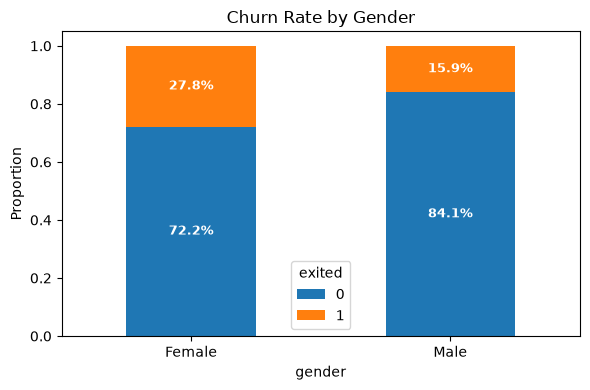

exited,0,1
gender,,
Female,55181,21244
Male,82890,15713


In [7]:
# ========================================
# GENDER ANALYSIS
# ========================================

df["gender"] = np.where(df["female"] == 1, "Female", "Male")

gender_churn = pd.crosstab(df["gender"], df["exited"], normalize="index")

ax = gender_churn.plot(kind="bar", stacked=True, figsize=(6, 4))
add_pct_labels(ax)

plt.title("Churn Rate by Gender")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(pd.crosstab(df["gender"], df["exited"]))


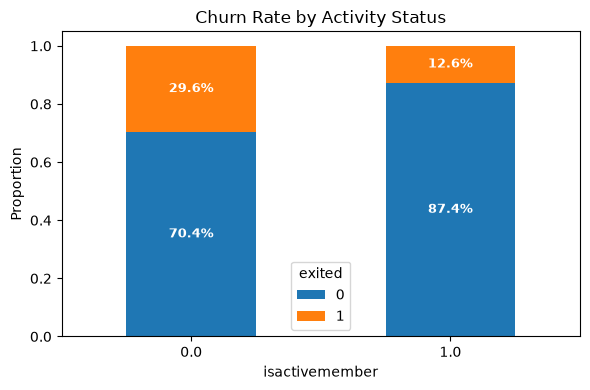

exited,0,1
isactivemember,,
0.0,61807,25925
1.0,76264,11032


In [8]:
# ========================================
# ACTIVE MEMBER ANALYSIS
# ========================================

active_churn = pd.crosstab(df["isactivemember"], df["exited"], normalize="index")

ax = active_churn.plot(kind="bar", stacked=True, figsize=(6, 4))
add_pct_labels(ax)

plt.title("Churn Rate by Activity Status")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(pd.crosstab(df["isactivemember"], df["exited"]))


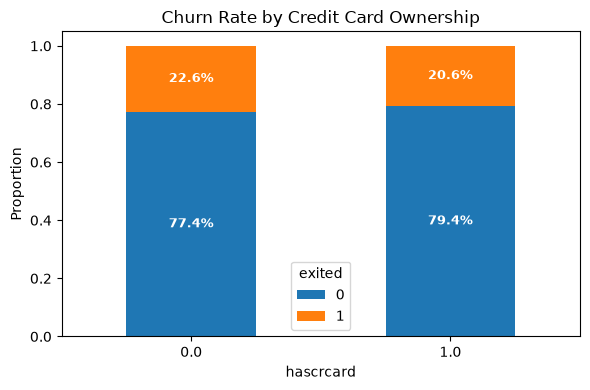

exited,0,1
hascrcard,,
0.0,33702,9848
1.0,104369,27109


In [9]:
# ========================================
# CREDIT CARD ANALYSIS
# ========================================

card_churn = pd.crosstab(df["hascrcard"], df["exited"], normalize="index")

ax = card_churn.plot(kind="bar", stacked=True, figsize=(6, 4))
add_pct_labels(ax)

plt.title("Churn Rate by Credit Card Ownership")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(pd.crosstab(df["hascrcard"], df["exited"]))


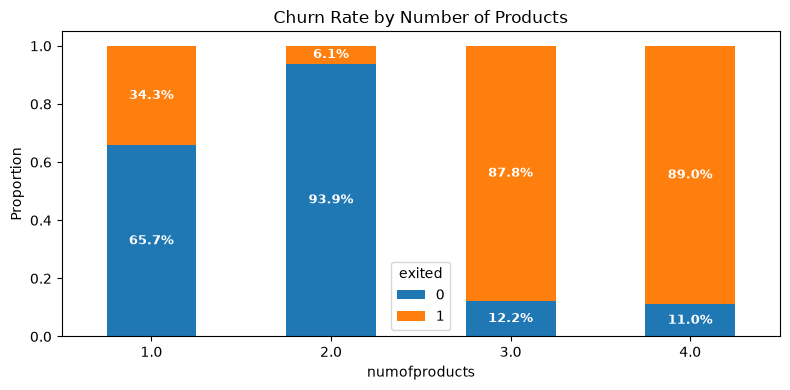

exited,0,1
numofproducts,,
1.0,54188,28267
2.0,83438,5440
3.0,386,2774
4.0,59,476


In [10]:
# ========================================
# NUMBER OF PRODUCTS ANALYSIS
# ========================================

num_product_churn = pd.crosstab(df["numofproducts"], df['exited'], normalize="index")

ax = num_product_churn.plot(kind="bar", stacked=True, figsize=(8, 4))
add_pct_labels(ax)

plt.title("Churn Rate by Number of Products")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(pd.crosstab(df["numofproducts"], df["exited"]))


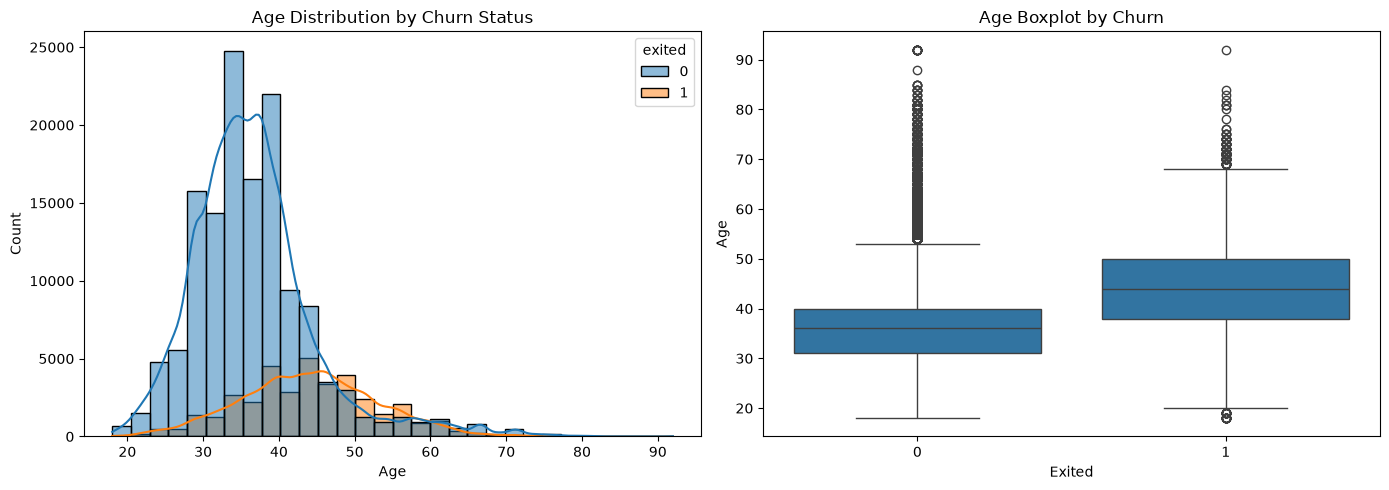

In [13]:
# ========================================
# AGE DISTRIBUTION BY CHURN
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#histogram
sns.histplot(
    data=df,
    x="age",
    hue="exited",
    kde=True, # this is the kernel density estimate, which gives a smooth curve over the histogram
    bins=30,
    ax=axes[0]
)
axes[0].set_title("Age Distribution by Churn Status")
axes[0].set_xlabel("Age")

sns.boxplot(
    data=df,
    x="exited",
    y="age",
    ax=axes[1]
)

axes[1].set_title("Age Boxplot by Churn")
axes[1].set_xlabel("Exited")
axes[1].set_ylabel("Age")

plt.tight_layout()
plt.show()


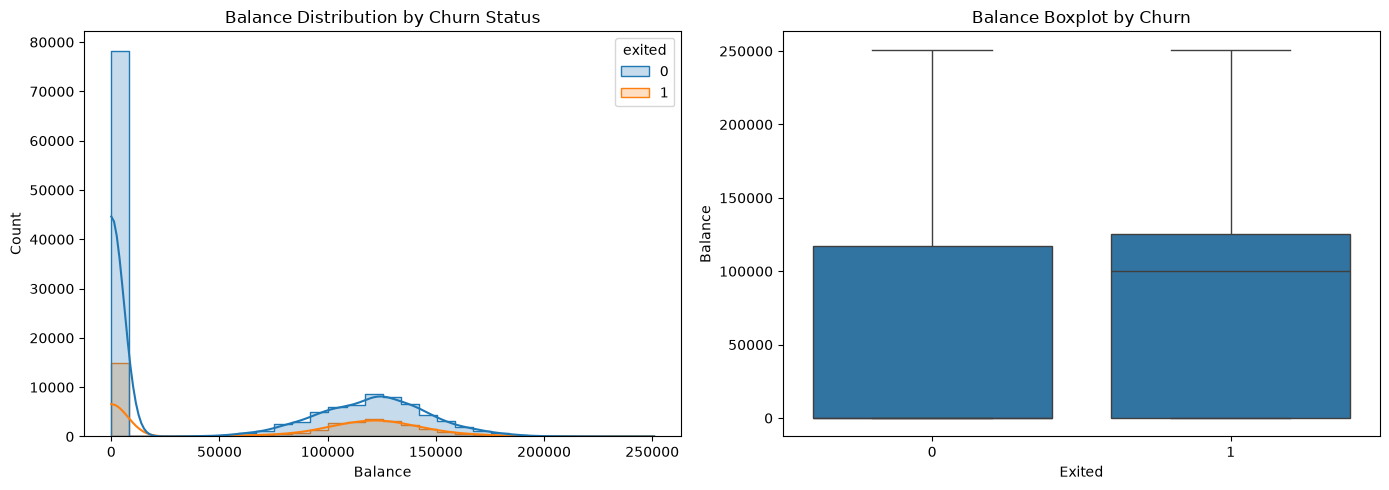

In [14]:
# ========================================
# BALANCE DISTRIBUTION BY CHURN 
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
sns.histplot(
    data=df,
    x="balance",
    hue="exited",
    kde=True,
    bins=30,
    element="step",
    ax=axes[0]
)

axes[0].set_title("Balance Distribution by Churn Status")
axes[0].set_xlabel("Balance")


sns.boxplot(
    data=df,
    x="exited",
    y="balance",
    ax=axes[1]
)

axes[1].set_title("Balance Boxplot by Churn")
axes[1].set_xlabel("Exited")
axes[1].set_ylabel("Balance")

plt.tight_layout()
plt.show()